# Analyst Coding Excercise


## Question 1
The data in table_1a.csv and table_1b.csv refers to an operational wind farm.

a. What is the total power in kW for operational turbines? That is, if all operational turbines were operating at their rated power, what would the total power of the wind farm be? What about non-operational turbines, what is the total power that is not operational?

b. How many turbines of each unique turbine model (based on rated power) are operational? 

c. In a single plot, display the turbine locations, their rated capacity and operational status.

In [ ]:
# imports
import pandas as pd
# read tables into dataframes
table1a = pd.read_csv("table_1a.csv")
table1b = pd.read_csv("table_1b.csv")
# show some basic info about the tables to get better understanding
print(table1a.info(verbose=True),'\n', table1a.describe(),'\n', table1a.head(n=5), '\n')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   turbine         25 non-null     int64  
 1   lat             25 non-null     float64
 2   lon             25 non-null     float64
 3   rated_power_kw  25 non-null     int64  
dtypes: float64(2), int64(2)
memory usage: 932.0 bytes
None 
          turbine        lat         lon  rated_power_kw
count  25.000000  25.000000   25.000000       25.000000
mean   13.000000  32.520084 -101.817373     2424.000000
std     7.359801   0.285786    0.043959      202.649122
min     1.000000  32.025694 -101.900000     2300.000000
25%     7.000000  32.319640 -101.846400     2300.000000
50%    13.000000  32.520905 -101.808923     2300.000000
75%    19.000000  32.704180 -101.781940     2500.000000
max    25.000000  32.982785 -101.761363     2800.000000 
    turbine        lat         lon  rated_power_kw
0        2

In [2]:
print(table1b.info(verbose=True),'\n', table1b.describe(),'\n', table1b.head(n=5), '\n')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   turbine_id   25 non-null     object
 1   operational  25 non-null     bool  
dtypes: bool(1), object(1)
memory usage: 357.0+ bytes
None 
        turbine_id operational
count          25          25
unique         25           2
top          T013        True
freq            1          18 
   turbine_id  operational
0       T013         True
1       T014         True
2       T015        False
3       T006         True
4      _T007         True 



- The info dump shows *table1a* containing details about the position in latitude and longitude as well as the rated_power_kw for 25 turbines. Along with *table1b* which has the turbine_id and the operational status also for 25 turbines.

- With both turbine and turbine_id, having 25 items, they seem to refer to the same thing. 

- So lets fix naming conventions to table1a standards and merge the two tables prove relation between turbine_id and turbine. 

In [3]:
# regex to only get the digits and typecast as int
table1b['turbine_id'] = table1b['turbine_id'].str.replace(r"[^0-9]+", '', regex=True).astype(int)

# merge and drop the turbine_id col since we're using table1a as standard
table1 = pd.merge(table1a, table1b, how="left", left_on="turbine", right_on="turbine_id")
table1 = table1.drop(columns=["turbine_id"])

# lets see those results
print(table1.head(10))

   turbine        lat         lon  rated_power_kw  operational
0        2  32.653019 -101.891187            2300         True
1        5  32.535653 -101.875779            2300         True
2        6  32.030058 -101.868732            2300         True
3        7  32.910851 -101.846400            2300         True
4        8  32.319640 -101.828968            2300         True
5        9  32.520905 -101.823943            2300        False
6       14  32.101579 -101.803300            2800         True
7       15  32.145035 -101.799257            2500        False
8       16  32.710153 -101.792582            2500        False
9       17  32.025694 -101.785406            2800        False


### 1a.
- With the data cleaned up, lets move on to 1a. 
- Operational and non-operational power can be found with conditional sum

In [4]:
operational_power = table1[table1["operational"] == True]["rated_power_kw"].sum()
non_operational_power = table1[table1["operational"] == False]["rated_power_kw"].sum()
print(f"Operational: {operational_power} kw\nNon-operational: {non_operational_power} kw")

Operational: 43600 kw
Non-operational: 17000 kw


### 1b.
- If the rated power refers to the turbine model then we can use a conditional value_counts of rated_power_kw

In [5]:
print(table1[table1["operational"] == True]["rated_power_kw"].value_counts())

rated_power_kw
2300    13
2800     4
2500     1
Name: count, dtype: int64


### 1c.
- We'll use matplotlib for all our plotting needs.
- Scatter plot with color based on power rating and a symbol based on operational status.
- Ideally we could use a map API to show the exact location using the latitude and longitude, but it seems a little out of scope for this exercise.

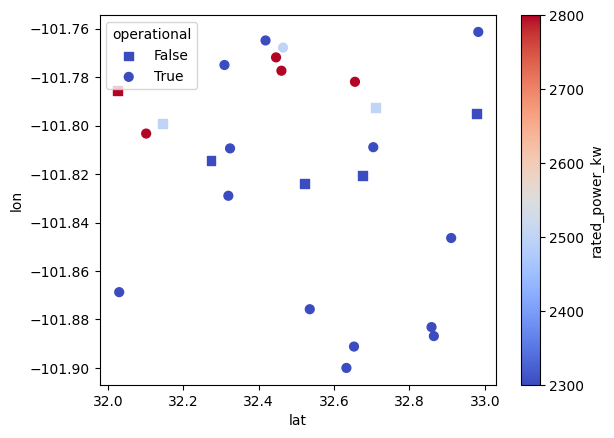

In [6]:
import matplotlib.pyplot as plt

for op, df in table1.groupby("operational"):
    sc = plt.scatter(df["lat"], df["lon"], c=df["rated_power_kw"],
                     cmap="coolwarm", marker="o" if op else "s", s=40, label=str(op))

plt.colorbar(sc, label="rated_power_kw")
plt.xlabel("lat")
plt.ylabel("lon")
plt.legend(title="operational")
plt.show()

## Question 2

The data in table_2.csv was extracted from the SCADA system of a solar farm that is expected to report data in 1-minute intervals but is experiencing some data quality issues.

a. Within the reported period between 7AM and 6PM, how many time intervals are expected? How many are missing? How many intervals are reported in the data but are not complete across all variables?

b. For each of the 3 sensors, compute the following summary statistics: mean, min and max.

- Similar to question 1, lets get a grasp on the data first.

In [ ]:
table2 = pd.read_csv("table_2.csv")

print(table2.info(verbose=True),'\n', table2.describe(),'\n', table2.head(n=5), '\n')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2492 entries, 0 to 2491
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp_est  2492 non-null   object 
 1   am_pm          2492 non-null   object 
 2   variable       2492 non-null   object 
 3   value          2396 non-null   float64
dtypes: float64(1), object(3)
memory usage: 78.0+ KB
None 
              value
count  2396.000000
mean    522.421239
std     282.851824
min      29.483334
25%     285.713280
50%     483.804165
75%     782.587037
max    1055.530900 
     timestamp_est am_pm  variable      value
0  9/12/2017 7:00    AM  power_kw  43.366665
1  9/12/2017 7:01    AM  power_kw  45.100000
2  9/12/2017 7:02    AM  power_kw  46.883335
3  9/12/2017 7:03    AM  power_kw  48.683334
4  9/12/2017 7:04    AM  power_kw  50.358334 



In [8]:
print(table2['variable'].unique())

['power_kw' 'irradiance_sensor1' 'irradiance_sensor2' 'irradiance_sensor3']


- Data has a variable and value columns, typical for long format tables, and testing that theory shows power_kw, irradiance_sensor1, irradiance_sensor2, and irradiance_sensor3 as the different variables
- Lets widen it and also convert the timestamps to the standard 24hr.

- I am making an assumption that est in timestamp_est means Eastern and will add the timezone info to the timestamp. This does not make any affect to our usage, and is merely for following standards.

In [9]:
table2["datetime"] = pd.to_datetime(table2["timestamp_est"] + ' ' + table2["am_pm"])

table2_pivot = table2.pivot(index="datetime", columns='variable', values="value")
table2_pivot.tz_localize(tz='US/Eastern')

variable,irradiance_sensor1,irradiance_sensor2,irradiance_sensor3,power_kw
datetime,,,,
2017-09-12 07:00:00-04:00,80.206460,84.877020,78.617090,43.366665
2017-09-12 07:01:00-04:00,82.840110,87.586550,81.079350,45.100000
2017-09-12 07:02:00-04:00,85.853775,90.295120,83.660160,46.883335
2017-09-12 07:03:00-04:00,88.955290,93.207160,86.352810,48.683334
2017-09-12 07:04:00-04:00,91.619705,96.110410,89.338920,50.358334
...,...,...,...,...
2017-09-12 17:56:00-04:00,68.883260,74.184950,71.781815,34.991665
2017-09-12 17:57:00-04:00,70.440610,74.050224,72.519920,35.875000
2017-09-12 17:58:00-04:00,66.434120,70.422780,68.697540,33.825000


### 2a.

- With the data cleaned up, we can get a better look at what information is missing.

In [10]:

print(f"""7AM to 6PM gives 11 hours of 1min interval\n 
Expecting: {11*60} intervals\n
Missing: {11*60} (Expected) - {table2_pivot.shape[0]} (rows) = {11*60 - table2_pivot.shape[0]}\n
Incomplete: {table2_pivot.shape[0]} (rows) - {table2_pivot.count(axis='columns').value_counts()[4]} (rows with all 4 values) = {table2_pivot.shape[0] - table2_pivot.count(axis='columns').value_counts()[4]}""")


7AM to 6PM gives 11 hours of 1min interval
 
Expecting: 660 intervals

Missing: 660 (Expected) - 623 (rows) = 37

Incomplete: 623 (rows) - 534 (rows with all 4 values) = 89


### 2b. 
- Formatting the values to 4 decimal points for display purposes

In [11]:
# 4 decimal places only for neatness
print(f"""
\tSensor1 \tSensor2 \tSensor3\n
mean:\t{table2_pivot['irradiance_sensor1'].mean():.4f} \t{table2_pivot['irradiance_sensor2'].mean():.4f} \t{table2_pivot['irradiance_sensor3'].mean():.4f}\n
min:\t{table2_pivot['irradiance_sensor1'].min():.4f} \t{table2_pivot['irradiance_sensor2'].min():.4f} \t{table2_pivot['irradiance_sensor3'].min():.4f}\n
max:\t{table2_pivot['irradiance_sensor1'].max():.4f} \t{table2_pivot['irradiance_sensor2'].max():.4f} \t{table2_pivot['irradiance_sensor3'].max():.4f}\n
""")



	Sensor1 	Sensor2 	Sensor3

mean:	573.6947 	597.6080 	594.0211

min:	58.8560 	68.2418 	64.9674

max:	1025.3668 	1054.5989 	1055.5309




## Question 3

Using the data from table_2.csv:
   
a. Infill the missing inverter power values to complete the 7AM to 6PM period of 1-minute resolution data using 2 (two) different methods that rely solely on the known power values.

b. Infill the missing inverter power values using 2 (two) methods that rely on sensor data.

Note: I will avoid using anything too fancy and focus on a clear reasoning and a putting an emphasis on understanding the data itself. Although using linear and random forest regression could potentially yield better results, those methods seem to have already been explored and I think it would do little for my evaluation to repeat it. 

### 3a.
-  Re-reading and formatting dataset to ensure purity
-  Lets also add the missing timestamp periods and set that as the index

In [ ]:
# add the missing timestamp indexes
table3 = pd.read_csv("table_2.csv")
table3["datetime"] = pd.to_datetime(table3["timestamp_est"] + ' ' + table3["am_pm"])
table3_pivot = table3.pivot(index="datetime", columns='variable', values="value")
table3_pivot.tz_localize(tz='US/Eastern')
# table has min 2017-09-12 07:00:00 and max 2017-09-12 18:00:00 so asfreq is sufficient
table3_pivot = table3_pivot.asfreq(freq="1min")
table3_pivot.index = pd.to_datetime(table3_pivot.index)
table3_pivot = table3_pivot.sort_index()


- Lets first plot out what the power_kw looks like to see what we're working with

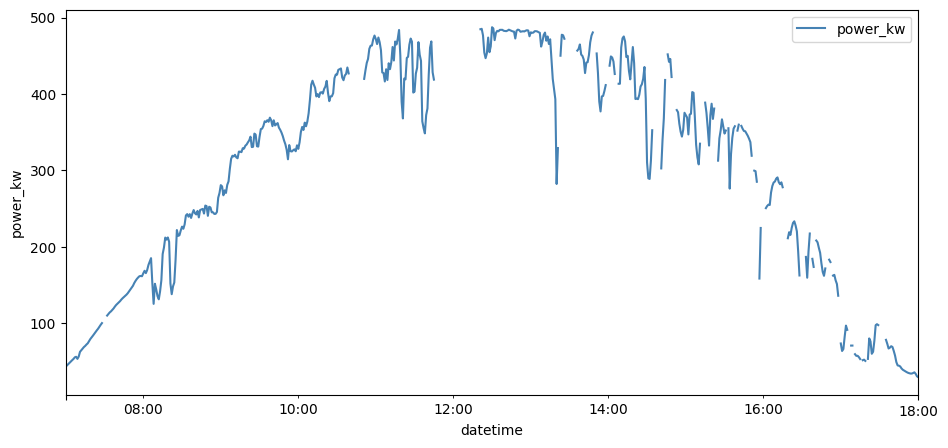

In [13]:
ax = table3_pivot["power_kw"].plot(figsize=(11,5), label="power_kw", color="steelblue")
plt.xlabel("datetime")
plt.ylabel("power_kw")
plt.legend()
plt.show()



- Lets also get some stats on continuity of missing values.

In [14]:
# contiguous missing values
is_null = table3_pivot['power_kw'].isna()

# grouping consecutive missing values under cumsum 
missing_id = (~is_null).cumsum()[is_null]

# get length of groups  
missing_length = missing_id.groupby(missing_id).size()
print(missing_length.describe())
print("Total missing power_kw values: ", len(table3_pivot.index) - table3_pivot[['power_kw']].count()['power_kw'])



count    34.000000
mean      3.176471
std       5.951677
min       1.000000
25%       1.000000
50%       2.000000
75%       3.000000
max      35.000000
Name: power_kw, dtype: float64
Total missing power_kw values:  108


**Observations** 
- With a mean of 3.17 length of contiguous missing values, most missing values are somewhat isolated, with the group around 12:00 as an outlier with 35 contiguous missing values.
- The majority of missing data is in the latter part of the day.
- The trend becomes more erratic at the end of the day.

**Thought Process**
- Lets choose our methods to prioritize a length 3 missing values as it makes up about 70% of missing power_kw data.
- Typically linear interpolation would be suited for these smaller gaps, but the erratic behaviour suggests methods like cubic spline would be preferred.
- So lets pit linear and cubic spline against each other.

**Univariate Methods**
1. Linear Interpolation
2. Cubic Spline Interpolation

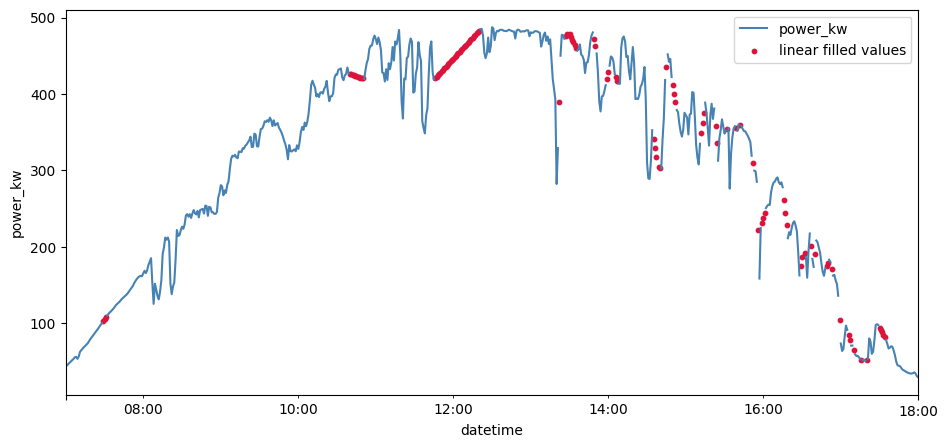

In [15]:
# Method 1: To give a greater weight to known values can take a more conservative approach with linear interpolation
table3a = table3_pivot.copy()
table3a['linear'] = pd.to_numeric(table3a['power_kw'].interpolate(method="linear"))
mask = table3a["power_kw"].isna() & table3a["linear"].notna()

ax = table3a["power_kw"].plot(figsize=(11,5), label="power_kw", color="steelblue")
ax.scatter(
    table3a.index[mask],
    table3a.loc[mask, "linear"],
    color="crimson",
    s=10,
    label="linear filled values"
)

plt.xlabel("datetime")
plt.ylabel("power_kw")
plt.legend()
plt.show()


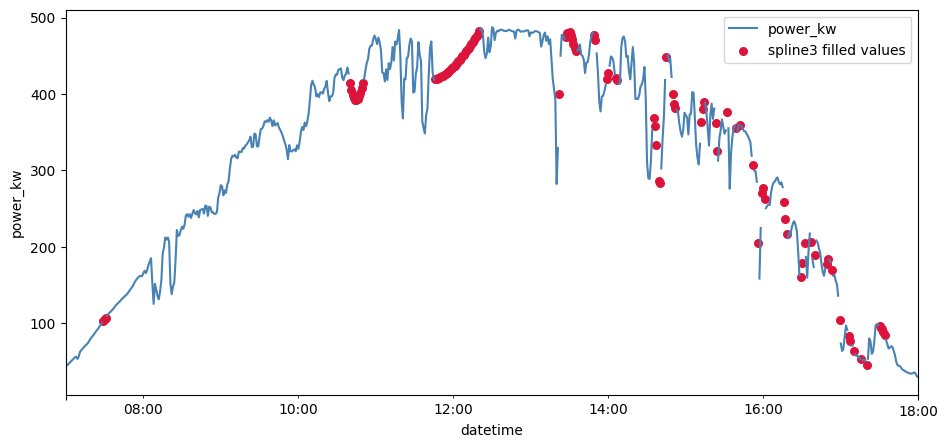

In [16]:

# Method 2: cubic spline fits well here with the shape of the fluctations 
table3a['spline3_power_kw'] = pd.to_numeric(table3a['power_kw'].interpolate(method="spline", order=3))

mask = table3a["power_kw"].isna() & table3a["spline3_power_kw"].notna()

ax = table3a["power_kw"].plot(figsize=(11,5), label="power_kw", color="steelblue")
ax.scatter(
    table3a.index[mask],
    table3a.loc[mask, "spline3_power_kw"],
    color="crimson",
    s=30,
    label="spline3 filled values"
)

plt.xlabel("datetime")
plt.ylabel("power_kw")
plt.legend()
plt.show()



- Lets also get a view of them together and plot the difference as well

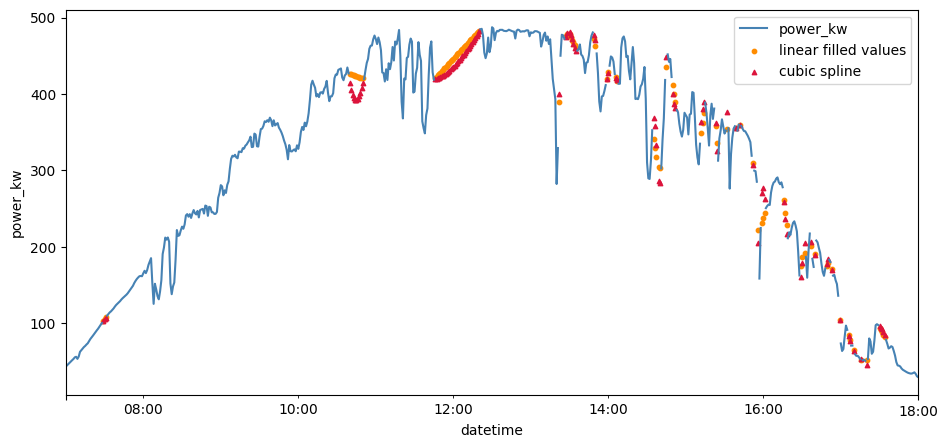

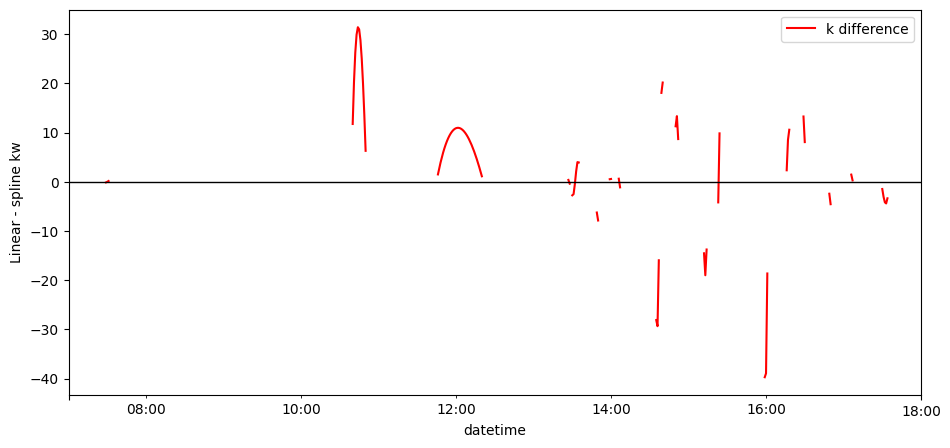


Linear Method: 
count    108.000000
mean     351.596643
std      133.963183
min       52.145833
25%      244.525000
50%      422.001388
75%      452.207870
max      482.885188
Name: linear, dtype: float64

Cubic Spline Method: 
count    108.000000
mean     348.424692
std      131.081930
min       45.567062
25%      268.894732
50%      403.537039
75%      443.335572
max      481.770621
Name: spline3_power_kw, dtype: float64

Linear - Spline: 
count    108.000000
mean       3.171952
std       12.503093
min      -39.713960
25%       -0.926217
50%        3.858577
75%       10.037263
max       31.400172
dtype: float64



In [36]:
linear = table3a["power_kw"].isna() & table3a["linear"].notna()
spline = table3a["power_kw"].isna() & table3a["spline3_power_kw"].notna()
diff = table3a.loc[table3a['power_kw'].isna(), 'linear'] - table3a.loc[table3a['power_kw'].isna(), 'spline3_power_kw']

# Both plots
ax = table3a["power_kw"].plot(figsize=(11,5), label="power_kw", color="steelblue")
ax.scatter(
    table3a.index[linear],
    table3a.loc[linear, "linear"],
    color="darkorange",
    s=10,
    label="linear filled values"
)
ax.scatter(
    table3a.index[spline],
    table3a.loc[spline, "spline3_power_kw"],
    color="crimson",
    s=10,
    marker='^',
    label="cubic spline"
)
plt.xlabel('datetime')
plt.ylabel('power_kw')
plt.legend()
plt.show()

# Graph of diffs
diff_full = diff.reindex(table3a.index)   
bx = diff_full.plot(figsize=(11, 5), color='red', label='k difference')
bx.bar(table3a.index[table3a['power_kw'].isna()], diff, width=11/600, color= ['darkorange' if v >= 0 else 'crimson' for v in diff])
bx.axhline(0, color='black', linewidth=1)
plt.xlabel('datetime')
plt.ylabel('Linear - spline kw')
plt.legend()
plt.show()

print(f"""
Linear Method: \n{table3a.loc[table3a['power_kw'].isna(), 'linear'].describe()}\n
Cubic Spline Method: \n{table3a.loc[table3a['power_kw'].isna(), 'spline3_power_kw'].describe()}\n
Linear - Spline: \n{diff.describe()}
""")

**Summary**
- We can see a mean of 3.17 for the difference between the linear and spline methods. This indicates that the 

### 3b


After some reading ive found that the efficiency of the sensors can change over the day 
with higher temps lowering output so lets do a constant efficiency value and rolling efficiency value so we can compare the two.

- Method 1: using a efficiency constant k = power_kw / avg_irradiance 
- Method 2: using a 1hr rolling window for efficiency constant k

> There are 37 rows that blank. I will be using linear interpolation across the columns for those blank cells for consitency and to keep our focus on our two methods.

38
Global efficiency constant k: 0.5311 kW per W/m²


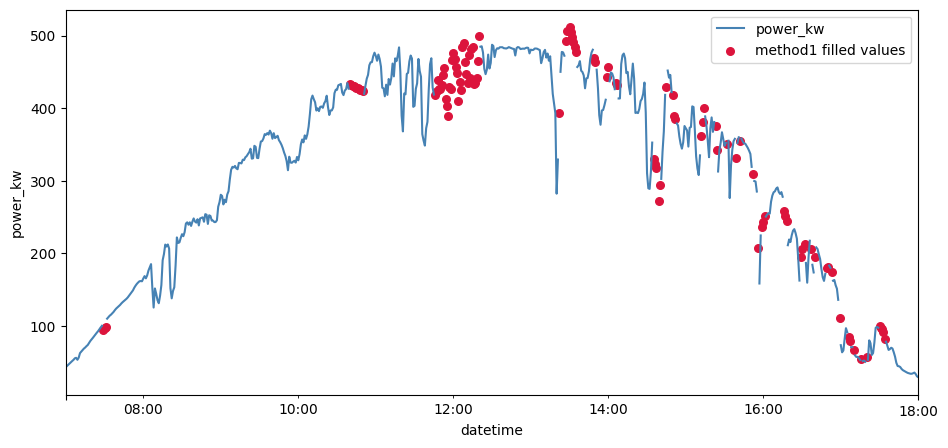

In [ ]:
# Method 1
table3b = table3_pivot.copy()
sensors = ['irradiance_sensor1', 'irradiance_sensor2', 'irradiance_sensor3']
table3b['avg_irradiance'] = table3b[sensors].mean(axis=1)

# linear interpolation where all 3 sensors are missing
table3b['avg_irradiance'] = table3b['avg_irradiance'].interpolate(method='linear')

# efficiency constant k averaged over all rows where both are known
known = table3b['power_kw'].notna() & table3b['avg_irradiance'].notna()
k = (table3b.loc[known, 'power_kw'] / table3b.loc[known, 'avg_irradiance']).mean()
print(f"Global efficiency constant k: {k:.4f} kW per W/m²")

missing_power = table3b['power_kw'].isna()
has_irradiance = table3b['avg_irradiance'].notna()

table3b['method1_const_eff'] = table3b['power_kw'].copy()
table3b.loc[missing_power & has_irradiance, 'method1_const_eff'] = (
    table3b.loc[missing_power & has_irradiance, 'avg_irradiance'] * k
)

# plot
mask = missing_power & has_irradiance
ax = table3b['power_kw'].plot(figsize=(11, 5), label='power_kw', color='steelblue')
ax.scatter(
    table3b.index[mask],
    table3b.loc[mask, 'method1_const_eff'],
    color='crimson', s=30, label='method1 filled values'
)
plt.xlabel('datetime')
plt.ylabel('power_kw')
plt.legend()
plt.show()


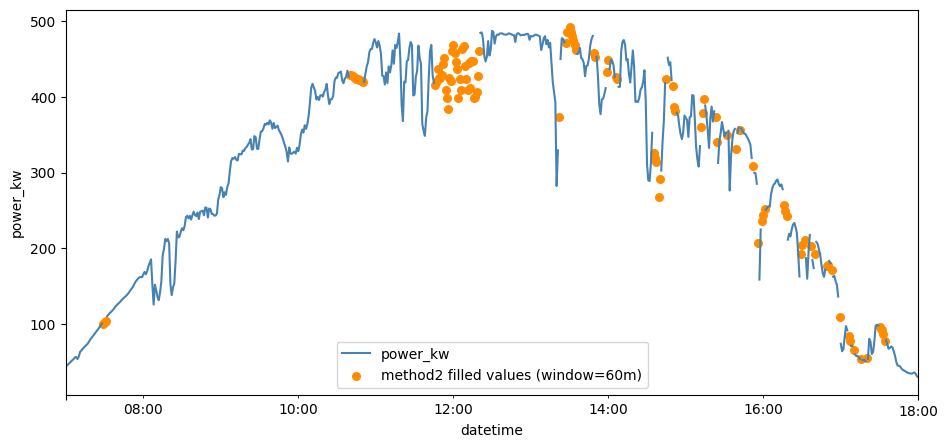

In [19]:

# Method 2

window = 60
table3b['efficiency'] = table3b['power_kw'] / table3b['avg_irradiance']


table3b['rolling_efficiency'] = (
    table3b['efficiency']
    .rolling(window=window, center=True, min_periods=1)
    .mean()
)

# bridge any remaining gaps left by the rolling window at the edges
table3b['rolling_efficiency'] = table3b['rolling_efficiency'].ffill().bfill()

missing_power = table3b['power_kw'].isna()
has_irradiance = table3b['avg_irradiance'].notna()

table3b['method2_rolling_eff'] = table3b['power_kw'].copy()
table3b.loc[missing_power & has_irradiance, 'method2_rolling_eff'] = (
    table3b.loc[missing_power & has_irradiance, 'avg_irradiance']
    * table3b.loc[missing_power & has_irradiance, 'rolling_efficiency']
)

# plot
mask = missing_power & has_irradiance
ax = table3b['power_kw'].plot(figsize=(11, 5), label='power_kw', color='steelblue')
ax.scatter(
    table3b.index[mask],
    table3b.loc[mask, 'method2_rolling_eff'],
    color='darkorange', s=30, label=f'method2 filled values (window={window}m)'
)
plt.xlabel('datetime')
plt.ylabel('power_kw')
plt.legend()
plt.show()


Filled rows compared: 108
Mean difference: -8.27678 kW
Mean absolute diff: 8.62822 kW
Max absolute diff: 39.77871 kW  at 12:20:00
STD: 10.26334 kW


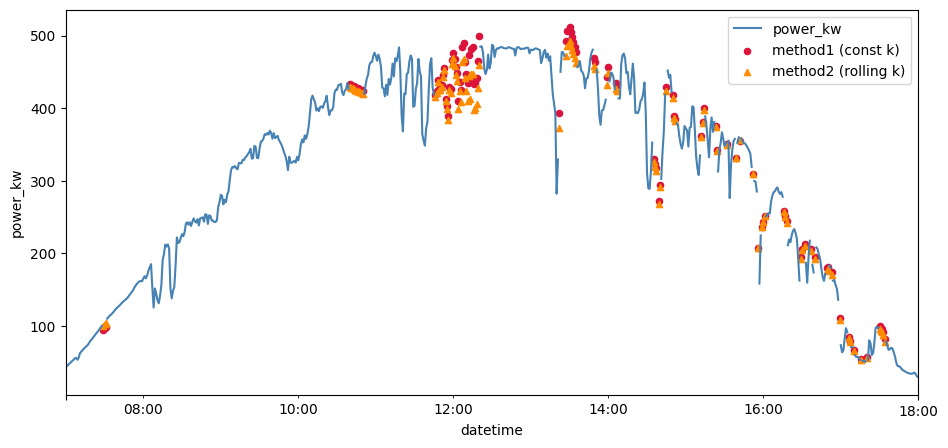

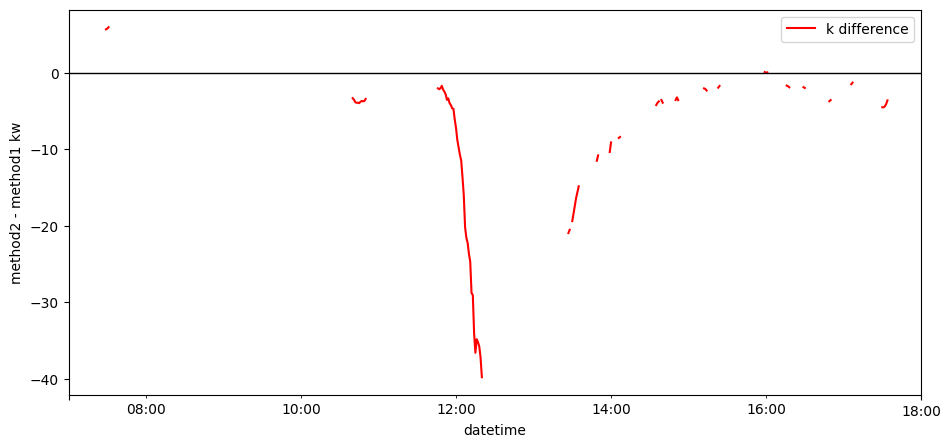

In [20]:

# compare methods only at the rows each one filled
filled = table3b['power_kw'].isna() & table3b['avg_irradiance'].notna()

diff = table3b.loc[filled, 'method2_rolling_eff'] - table3b.loc[filled, 'method1_const_eff']

print(f"Filled rows compared: {filled.sum()}")
print(f"Mean difference: {diff.mean():.5f} kW")
print(f"Mean absolute diff: {diff.abs().mean():.5f} kW")
print(f"Max absolute diff: {diff.abs().max():.5f} kW  at {diff.abs().idxmax().time()}")
print(f"STD: {diff.std():.5f} kW")


ax = table3b['power_kw'].plot(figsize=(11, 5), color='steelblue', label='power_kw')
ax.scatter(table3b.index[filled], table3b.loc[filled, 'method1_const_eff'],
                color='crimson', s=20, label='method1 (const k)')
ax.scatter(table3b.index[filled], table3b.loc[filled, 'method2_rolling_eff'],
                color='darkorange', s=20, label='method2 (rolling k)', marker='^')
plt.xlabel('datetime')
plt.ylabel('power_kw')
plt.legend()
plt.show()

x_vals = table3b.index
diff_full = diff.reindex(x_vals)   # align to first plot's x-axis

bx = diff_full.plot(figsize=(11, 5), color='red', label='k difference')
bx.bar(table3b.index[filled], diff, width=11/600, color= ['darkorange' if v >= 0 else 'crimson' for v in diff])
bx.axhline(0, color='black', linewidth=1)
plt.xlabel('datetime')
plt.ylabel('method2 - method1 kw')
plt.legend()
plt.show()



Looking at the plot you can see a difference of around 8 kw given by method 2 as opposed to method 1. The temperature of the panel is supposed to lower the efficiency of the power generation and it looks like that holds true considering the difference raising at noon when temperatures peak.

<Axes: >

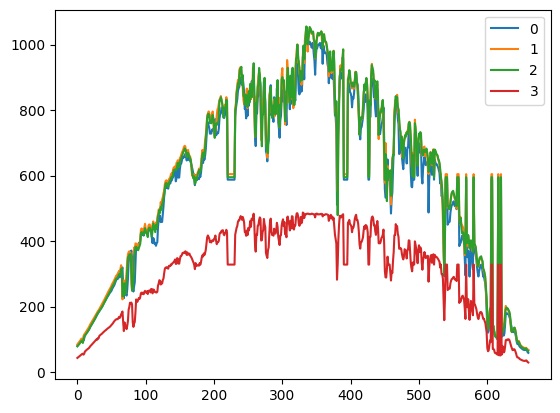

In [ ]:
table3_regression = table3_pivot.copy()
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge, LinearRegression # Default estimator

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor

features = ['irradiance_sensor1', 'irradiance_sensor2', 'irradiance_sensor3']
target = 'power_kw'

imputer = IterativeImputer(estimator=KNeighborsRegressor() ,max_iter=10, random_state=0)
imputed = pd.DataFrame(imputer.fit_transform(table3_regression))
imputed.plot()

# mask = table3_regression['power_kw'].isna() & imputed[3].notna()
# ax = table3_regression['power_kw'].plot(figsize=(11, 5), label='power_kw', color='steelblue')
# ax.scatter(
#     imputed[3].index[table3_regression['power_kw'].isna()],
#     imputed.loc[mask, 3],
#     color='darkorange', s=30, label='imputed'
# )
# plt.xlabel('datetime')
# plt.ylabel('power_kw')
# plt.legend()
# plt.show()

# Fit and transform the data
# The imputer works directly on the numerical values
# df_imputed = pd.DataFrame(imputer.fit_transform(table3_regression), columns=table3_regression.columns)

# These values have few missing data but needs to be not nan
# table3_regression[features] = table3_regression[features].interpolate(method='spline', limit_direction='both', order=3)
# X = table3_regression.loc[~table3_regression[target].isna(), features] # Define features
# y = table3_regression.loc[~table3_regression[target].isna(), target] # Define target
# z = table3_regression.loc[table3_regression[target].isna(), target] # Missing values
# Split data to train and test
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)